
[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import arxiv
client =arxiv.Client()
def collect_arxiv_papers(catagory:str, max_results=100):
  search=arxiv.Search(
      query=f"cat:{catagory}",
      max_results=max_results,
      sort_by=arxiv.SortCriterion.LastUpdatedDate
  )
  papers=[]
  for result in client.results(search):
    paper={
        'title':result.title,
        'authors':[author.name for author in result.authors],
        'abstract':result.summary,
        'published':result.published,
        'catagory':catagory,
        'arxiv_id':result.entry_id.split('/')[-1]
    }
    papers.append(paper)
  return papers

catagories=[
    ('cs.LG', 'Machine Learning'),
    ('cs.CV', 'Computer Vision'),
    ('cs.CL', 'Computational Linguistics'),
    ('cs.DB', 'Databases'),
    ('cs.SE', 'Software Engineering')
  ]
all_papers=[]
for catagory_code, catagory_name in catagories:
  print(f"printing papers from {catagory_name} ({catagory_code})")
  papers=collect_arxiv_papers(catagory_code, max_results=100)
  all_papers.extend(papers)
  print(f"collected {len(papers)} papers")
### Let's examine the first paper from each category
separator = "=" * 80
print(f"\n{separator}", "SAMPLE PAPERS (one from each category)", f"{separator}", sep="\n")
for i, (_, category_name) in enumerate(catagories):
    paper = all_papers[i * 100]
    print(f"\n{category_name}:")
    print(f"  Title: {paper['title']}")
    print(f"  Abstract (first 150 chars): {paper['abstract'][:150]}...")

printing papers from Machine Learning (cs.LG)
collected 100 papers
printing papers from Computer Vision (cs.CV)
collected 100 papers
printing papers from Computational Linguistics (cs.CL)
collected 100 papers
printing papers from Databases (cs.DB)
collected 100 papers
printing papers from Software Engineering (cs.SE)
collected 100 papers

SAMPLE PAPERS (one from each category)

Machine Learning:
  Title: Differential privacy representation geometry for medical image analysis
  Abstract (first 150 chars): Differential privacy (DP)'s effect in medical imaging is typically evaluated only through end-to-end performance, leaving the mechanism of privacy-ind...

Computer Vision:
  Title: Repurposing 3D Generative Model for Autoregressive Layout Generation
  Abstract (first 150 chars): We introduce LaviGen, a framework that repurposes 3D generative models for 3D layout generation. Unlike previous methods that infer object layouts fro...

Computational Linguistics:
  Title: Author-in-the-Loop 

In [5]:
import pandas as pd
#channging the above dataset into frame for easier visualization
df=pd.DataFrame(all_papers)
df.head()

,title,authors,abstract,published,catagory,arxiv_id
0,Differential privacy representation geometry f...,"[Soroosh Tayebi Arasteh, Marziyeh Mohammadi, S...",Differential privacy (DP)'s effect in medical ...,2026-03-01 13:30:36+00:00,cs.LG,2603.01098v2
1,Modeling Parkinson's Disease Progression Using...,"[Ran Tong, Lanruo Wang, Tong Wang, Wei Yan]",Predicting Parkinson's Disease (PD) progressio...,2025-07-26 20:56:32+00:00,cs.LG,2507.20058v3
2,Structural Evaluation Metrics for SVG Generati...,"[Haonan Zhu, Adrienne Deganutti, Elad Hirsch, ...",SVG generation is typically evaluated by compa...,2026-04-09 22:50:41+00:00,cs.LG,2604.08809v2
3,Benchmarking Optimizers for MLPs in Tabular De...,"[Yury Gorishniy, Ivan Rubachev, Dmitrii Feokti...",MLP is a heavily used backbone in modern deep ...,2026-04-16 17:57:02+00:00,cs.LG,2604.15297v2
4,Geometric regularization of autoencoders via o...,"[Sean Hill, Felix X. -F. Ye]",Stochastic dynamical systems with slow or meta...,2026-04-17 17:44:02+00:00,cs.LG,2604.16282v1


In [6]:
len(df)

500

In [7]:
print(f"Papers with abstracts: {df['abstract'].notna().sum()}")

Papers with abstracts: 500


In [8]:
missing_abstracts = df['abstract'].isna().sum()
print(missing_abstracts)

0


In [9]:
df['abstract_length'] = df['abstract'].str.len()

In [10]:
df.head()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length
0,Differential privacy representation geometry f...,"[Soroosh Tayebi Arasteh, Marziyeh Mohammadi, S...",Differential privacy (DP)'s effect in medical ...,2026-03-01 13:30:36+00:00,cs.LG,2603.01098v2,1458
1,Modeling Parkinson's Disease Progression Using...,"[Ran Tong, Lanruo Wang, Tong Wang, Wei Yan]",Predicting Parkinson's Disease (PD) progressio...,2025-07-26 20:56:32+00:00,cs.LG,2507.20058v3,1474
2,Structural Evaluation Metrics for SVG Generati...,"[Haonan Zhu, Adrienne Deganutti, Elad Hirsch, ...",SVG generation is typically evaluated by compa...,2026-04-09 22:50:41+00:00,cs.LG,2604.08809v2,1120
3,Benchmarking Optimizers for MLPs in Tabular De...,"[Yury Gorishniy, Ivan Rubachev, Dmitrii Feokti...",MLP is a heavily used backbone in modern deep ...,2026-04-16 17:57:02+00:00,cs.LG,2604.15297v2,964
4,Geometric regularization of autoencoders via o...,"[Sean Hill, Felix X. -F. Ye]",Stochastic dynamical systems with slow or meta...,2026-04-17 17:44:02+00:00,cs.LG,2604.16282v1,1855


In [11]:
df.tail()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length
495,Learning from Change: Predictive Models for In...,"[Eileen Kapel, Jan Lennartz, Luis Cruz, Diomid...",Effective IT change management is important fo...,2026-04-15 04:33:46+00:00,cs.SE,2604.13462v1,1283
496,Programming Language Co-Usage Patterns on Stac...,"[Bachan Ghimire, Nitin Gupta]",Understanding how developers combine programmi...,2026-04-13 23:04:22+00:00,cs.SE,2604.12123v2,1396
497,The Cognitive Circuit Breaker: A Systems Engin...,[Jonathan Pan],As Large Language Models (LLMs) are increasing...,2026-04-15 02:34:37+00:00,cs.SE,2604.13417v1,1276
498,BugScope: Learn to Find Bugs Like Human,"[Jinyao Guo, Chengpeng Wang, Dominic Deluca, J...",Software auditing is an increasingly critical ...,2025-07-21 14:34:01+00:00,cs.SE,2507.15671v2,1288
499,LLM-Enabled Open-Source Systems in the Wild: A...,"[Fariha Tanjim Shifat, Hariswar Baburaj, Ce Zh...",Large language models (LLMs) are increasingly ...,2026-04-05 22:07:31+00:00,cs.SE,2604.04288v2,1280


In [12]:
len(df[df['abstract_length']<100])

0

In [13]:
print(f"Average abstract length: {df['abstract_length'].mean():.0f} characters")

Average abstract length: 1365 characters


In [14]:
print(df['catagory'].value_counts().sort_index())

catagory
cs.CL    100
cs.CV    100
cs.DB    100
cs.LG    100
cs.SE    100
Name: count, dtype: int64


In [18]:
separator = "=" * 80
print(f"\n{separator}", "FIRST 3 PAPERS IN CLEANED DATASET", f"{separator}", sep="\n")
for idx, row in df.head(3).iterrows():
    print(f"\n{idx+1}. {row['title']}")
    print(f"   Catagory: {row['catagory']}")
    print(f"   Abstract length: {row['abstract_length']} characters")


FIRST 3 PAPERS IN CLEANED DATASET

1. Differential privacy representation geometry for medical image analysis
   Catagory: cs.LG
   Abstract length: 1458 characters

2. Modeling Parkinson's Disease Progression Using Longitudinal Voice Biomarkers: A Comparative Study of Statistical and Neural Mixed-Effects Models
   Catagory: cs.LG
   Abstract length: 1474 characters

3. Structural Evaluation Metrics for SVG Generation via Leave-One-Out Analysis
   Catagory: cs.LG
   Abstract length: 1120 characters


In [17]:
from sentence_transformers import SentenceTransformer
import numpy as np
import time

In [19]:
print("Loading all-MiniLM-L6-v2 model...")
small_model=SentenceTransformer('all-MiniLM-L6-v2')
abstracts=df['abstract'].tolist()
print(f"generating embeding for {len(abstracts)} papers")
start=time.time()
embeddings_small=small_model.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32
)
elapsed_time=time.time() - start
print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_small.shape}")



Loading all-MiniLM-L6-v2 model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     | Details
------------------------+------------+--------
embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generating embeding for 500 papers


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Completed in 51.10 seconds
Embedding shape: (500, 384)


In [20]:
print(f"Each abstract is now a {embeddings_small.shape[1]}-dimensional vector")

Each abstract is now a 384-dimensional vector


In [21]:
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

Average time per abstract: 0.102 seconds


In [22]:
df['embedding_minilm'] = list(embeddings_small)

In [23]:
df.head()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length,embedding_minilm
0,Differential privacy representation geometry f...,"[Soroosh Tayebi Arasteh, Marziyeh Mohammadi, S...",Differential privacy (DP)'s effect in medical ...,2026-03-01 13:30:36+00:00,cs.LG,2603.01098v2,1458,"[-0.05411912, -0.04547766, 0.006096536, -0.011..."
1,Modeling Parkinson's Disease Progression Using...,"[Ran Tong, Lanruo Wang, Tong Wang, Wei Yan]",Predicting Parkinson's Disease (PD) progressio...,2025-07-26 20:56:32+00:00,cs.LG,2507.20058v3,1474,"[-0.034831714, -0.114969894, 0.0640307, 0.0408..."
2,Structural Evaluation Metrics for SVG Generati...,"[Haonan Zhu, Adrienne Deganutti, Elad Hirsch, ...",SVG generation is typically evaluated by compa...,2026-04-09 22:50:41+00:00,cs.LG,2604.08809v2,1120,"[-0.007680216, 0.017612752, 0.027466334, 0.038..."
3,Benchmarking Optimizers for MLPs in Tabular De...,"[Yury Gorishniy, Ivan Rubachev, Dmitrii Feokti...",MLP is a heavily used backbone in modern deep ...,2026-04-16 17:57:02+00:00,cs.LG,2604.15297v2,964,"[-0.058084056, -0.09363667, 0.09572814, -0.032..."
4,Geometric regularization of autoencoders via o...,"[Sean Hill, Felix X. -F. Ye]",Stochastic dynamical systems with slow or meta...,2026-04-17 17:44:02+00:00,cs.LG,2604.16282v1,1855,"[-0.02181639, -0.092179865, 0.041144803, 0.057..."


In [ ]:
print("\nLoading all-mpnet-base-v2 model...")
model_large = SentenceTransformer('all-mpnet-base-v2')

print("Generating embeddings with larger model...")
start_time = time.time()
embeddings_large = model_large.encode(
    abstracts,
    show_progress_bar=True,
    batch_size=32
)
elapsed_time = time.time() - start_time
print(f"\nCompleted in {elapsed_time:.2f} seconds")
print(f"Embedding shape: {embeddings_large.shape}")
print(f"Each abstract is now a {embeddings_large.shape[1]}-dimensional vector")
print(f"Average time per abstract: {elapsed_time/len(abstracts):.3f} seconds")

### Add these embeddings to our DataFrame too
df['embedding_mpnet'] = list(embeddings_large)


Loading all-mpnet-base-v2 model...


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [22]:
df.head()

,title,authors,abstract,published,catagory,arxiv_id,abstract_length,embedding_minilm,embedding_mpnet
0,Generalization in LLM Problem Solving: The Cas...,"[Yao Tong, Jiayuan Ye, Anastasia Borovykh, Rez...",Whether language models can systematically gen...,2026-04-16 17:59:43+00:00,cs.LG,2604.15306v1,1031,"[0.035906725, -0.07353913, 0.1057131, 0.058427...","[0.042266235, 0.07422793, -0.022473667, -0.018..."
1,Diagnosing LLM Judge Reliability: Conformal Pr...,"[Manan Gupta, Dhruv Kumar]",LLM-as-judge frameworks are increasingly used ...,2026-04-16 17:58:21+00:00,cs.LG,2604.15302v1,1239,"[0.018621435, -0.031659197, -0.017490719, 0.01...","[0.037717517, 0.050923824, 0.0024065417, 0.005..."
2,Benchmarking Optimizers for MLPs in Tabular De...,"[Yury Gorishniy, Ivan Rubachev, Dmitrii Feokti...",MLP is a heavily used backbone in modern deep ...,2026-04-16 17:57:02+00:00,cs.LG,2604.15297v1,982,"[-0.06885764, -0.10043863, 0.086874746, -0.028...","[-0.050479256, 0.10648612, 0.006030702, 0.0165..."
3,Structural interpretability in SVMs with trunc...,"[Víctor Soto-Larrosa, Nuria Torrado, Edmundo J...",We study post-training interpretability for Su...,2026-04-16 17:52:08+00:00,cs.LG,2604.15285v1,1055,"[-0.024285965, -0.095913224, -0.023772549, 0.0...","[-0.02999782, 0.025270518, 0.00050496176, 0.03..."
4,How Embeddings Shape Graph Neural Networks: Cl...,"[Nouhaila Innan, Antonello Rosato, Alberto Mar...",Node embeddings act as the information interfa...,2026-04-16 17:45:24+00:00,cs.LG,2604.15273v1,1280,"[-0.047760405, -0.059560154, 0.015015715, 0.04...","[-0.028083468, 0.050877403, 0.012452031, 0.018..."


In [23]:
!pip install scikit-learn
!pip install matplotlib

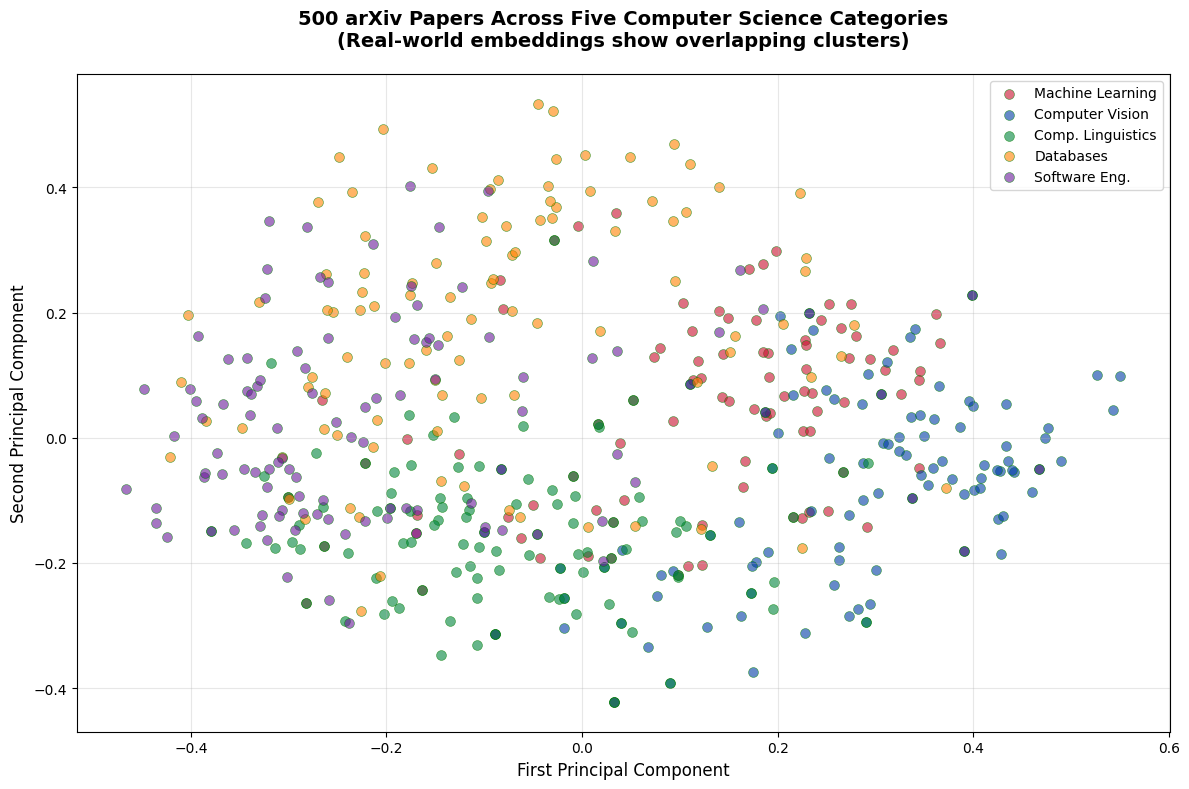

In [25]:
import sklearn
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
embeddings_2d=pca.fit_transform(embeddings_small)
plt.figure(figsize=(12, 8))
colors = ['#C8102E', '#003DA5', '#00843D', '#FF8200', '#6A1B9A']
category_names = ['Machine Learning', 'Computer Vision', 'Comp. Linguistics', 'Databases', 'Software Eng.']
category_codes = ['cs.LG', 'cs.CV', 'cs.CL', 'cs.DB', 'cs.SE']
for i, (cat_code, cat_name, color) in enumerate(zip(category_codes, category_names, colors)):
    mask = df['catagory'] == cat_code
    cat_embeddings = embeddings_2d[mask]
    plt.scatter(cat_embeddings[:, 0], cat_embeddings[:, 1],
                c=color, label=cat_name, s=50, alpha=0.6, edgecolors='green', linewidth=0.5)
plt.xlabel('First Principal Component', fontsize=12)
plt.ylabel('Second Principal Component', fontsize=12)
plt.title('500 arXiv Papers Across Five Computer Science Categories\n(Real-world embeddings show overlapping clusters)',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [26]:
category_codes = ['cs.LG']
for cat_code in catagories:
  mask=df['catagory']==cat_code
mask

,catagory
0,False
1,False
2,False
3,False
4,False
...,...
495,False
496,False
497,False
498,False


In [ ]:
print("Generating embeddings using Cohere API...")
print(f"Processing {len(abstracts)} abstracts...")

start_time = time.time()
actual_api_time = 0  # Track time spent on actual API calls

### Cohere recommends processing in batches for efficiency
### Their API accepts up to 96 texts per request
batch_size = 90
all_embeddings = []

for i in range(0, len(abstracts), batch_size):
    batch = abstracts[i:i+batch_size]
    batch_num = i//batch_size + 1
    total_batches = (len(abstracts) + batch_size - 1) // batch_size
    print(f"Processing batch {batch_num}/{total_batches} ({len(batch)} abstracts)...")

    # Add retry logic for rate limits
    max_retries = 3
    retry_delay = 60  # Wait 60 seconds if we hit rate limit

    for attempt in range(max_retries):
        try:
            # Track actual API call time
            api_start = time.time()

            # Generate embeddings for this batch using V2 API
            response = co.embed(
                texts=batch,
                model='embed-v4.0',
                input_type='search_document',
                embedding_types=['float']
            )

            actual_api_time += time.time() - api_start
            # V2 API returns embeddings in a different structure
            all_embeddings.extend(response.embeddings.float_)
            break  # Success, move to next batch

        except Exception as e:
            if "rate limit" in str(e).lower() and attempt < max_retries - 1:
                print(f"  Rate limit hit. Waiting {retry_delay} seconds before retry...")
                time.sleep(retry_delay)
            else:
                raise  # Re-raise if it's not a rate limit error or we're out of retries

    # Add a delay between batches to avoid hitting rate limits
    # Wait 12 seconds between batches (spreads 500 papers over ~1 minute)
    if i + batch_size < len(abstracts):  # Don't wait after the last batch
        time.sleep(12)

### Convert to numpy array for consistency with local models
embeddings_cohere = np.array(all_embeddings)
elapsed_time = time.time() - start_time

print(f"\nCompleted in {elapsed_time:.2f} seconds (includes rate limit delays)")
print(f"Actual API processing time: {actual_api_time:.2f} seconds")
print(f"Time spent waiting for rate limits: {elapsed_time - actual_api_time:.2f} seconds")
print(f"Embedding shape: {embeddings_cohere.shape}")
print(f"Each abstract is now a {embeddings_cohere.shape[1]}-dimensional vector")
print(f"Average time per abstract (API only): {actual_api_time/len(abstracts):.3f} seconds")

### Add to DataFrame
df['embedding_cohere'] = list(embeddings_cohere)

NameError: name 'new' is not defined